In [1]:
import torch
from torch import nn
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv, GATConv

C:\Users\praveenchakra.bh\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = Planetoid(root='datasets/Planetoid', name='Cora', transform=NormalizeFeatures())

In [3]:
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Number of graphs: 1
Number of features: 1433
Number of classes: 7


In [4]:
data = dataset[0]
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')

Number of nodes: 2708
Number of edges: 10556


In [5]:
print(data)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [6]:
import torch.nn.functional as F

class GraphCNN(nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.conv1 = GCNConv(dataset.num_features, self.hidden_channels)
        self.conv2 = GCNConv(self.hidden_channels, dataset.num_classes)
        self.relu = nn.ReLU()

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [7]:
model = GraphCNN(hidden_channels=16)

In [8]:
model

GraphCNN(
  (conv1): GCNConv(1433, 16)
  (conv2): GCNConv(16, 7)
  (relu): ReLU()
)

In [10]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

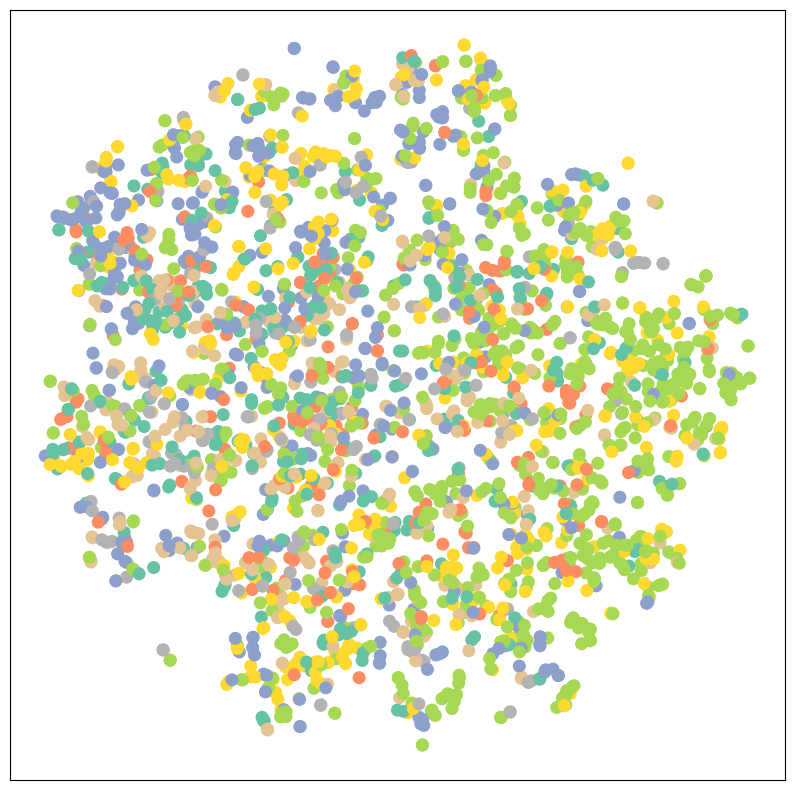

In [11]:
out = model(data.x, data.edge_index)
visualize(out, color=data.y)

In [12]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

In [13]:
from tqdm import tqdm

for epoch in tqdm(range(1, 101)):
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

 15%|███▏                 | 15/100 [00:00<00:01, 71.68it/s]

Epoch: 001, Loss: 1.9466
Epoch: 002, Loss: 1.9412
Epoch: 003, Loss: 1.9345
Epoch: 004, Loss: 1.9282
Epoch: 005, Loss: 1.9213
Epoch: 006, Loss: 1.9133
Epoch: 007, Loss: 1.9048
Epoch: 008, Loss: 1.8948
Epoch: 009, Loss: 1.8857
Epoch: 010, Loss: 1.8729
Epoch: 011, Loss: 1.8621
Epoch: 012, Loss: 1.8542
Epoch: 013, Loss: 1.8408
Epoch: 014, Loss: 1.8339
Epoch: 015, Loss: 1.8224
Epoch: 016, Loss: 1.8188
Epoch: 017, Loss: 1.8023
Epoch: 018, Loss: 1.7932


 35%|███████▎             | 35/100 [00:00<00:00, 84.73it/s]

Epoch: 019, Loss: 1.7734
Epoch: 020, Loss: 1.7638
Epoch: 021, Loss: 1.7467
Epoch: 022, Loss: 1.7262
Epoch: 023, Loss: 1.7027
Epoch: 024, Loss: 1.6882
Epoch: 025, Loss: 1.6857
Epoch: 026, Loss: 1.6602
Epoch: 027, Loss: 1.6576
Epoch: 028, Loss: 1.6252
Epoch: 029, Loss: 1.6153
Epoch: 030, Loss: 1.5858
Epoch: 031, Loss: 1.5900
Epoch: 032, Loss: 1.5645
Epoch: 033, Loss: 1.5227
Epoch: 034, Loss: 1.5242
Epoch: 035, Loss: 1.4890
Epoch: 036, Loss: 1.4802
Epoch: 037, Loss: 1.4646
Epoch: 038, Loss: 1.3884


 54%|███████████▎         | 54/100 [00:00<00:00, 88.11it/s]

...

Epoch: 059, Loss: 0.9887
Epoch: 060, Loss: 0.9832
Epoch: 061, Loss: 0.9430
Epoch: 062, Loss: 0.9389
Epoch: 063, Loss: 0.9496
Epoch: 064, Loss: 0.9607
Epoch: 065, Loss: 0.8885
Epoch: 066, Loss: 0.8867
Epoch: 067, Loss: 0.8957
Epoch: 068, Loss: 0.8847
Epoch: 069, Loss: 0.8515
Epoch: 070, Loss: 0.8464
Epoch: 071, Loss: 0.7940
Epoch: 072, Loss: 0.7692
Epoch: 073, Loss: 0.7773
Epoch: 074, Loss: 0.7647


 81%|█████████████████    | 81/100 [00:00<00:00, 80.78it/s]

Epoch: 075, Loss: 0.7566
Epoch: 076, Loss: 0.7640
Epoch: 077, Loss: 0.7655
Epoch: 078, Loss: 0.7146
Epoch: 079, Loss: 0.7516
Epoch: 080, Loss: 0.7094
Epoch: 081, Loss: 0.7208
Epoch: 082, Loss: 0.6793
Epoch: 083, Loss: 0.6794
Epoch: 084, Loss: 0.6785
Epoch: 085, Loss: 0.7066
Epoch: 086, Loss: 0.6630
Epoch: 087, Loss: 0.7193
Epoch: 088, Loss: 0.6610
Epoch: 089, Loss: 0.6444
Epoch: 090, Loss: 0.6427


100%|████████████████████| 100/100 [00:01<00:00, 80.65it/s]

Epoch: 091, Loss: 0.6070
Epoch: 092, Loss: 0.5972
Epoch: 093, Loss: 0.6276
Epoch: 094, Loss: 0.6013
Epoch: 095, Loss: 0.5725
Epoch: 096, Loss: 0.5741
Epoch: 097, Loss: 0.5211
Epoch: 098, Loss: 0.6048
Epoch: 099, Loss: 0.5539
Epoch: 100, Loss: 0.5640


In [14]:
def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    test_correct = pred[data.test_mask] == data.y[data.test_mask]  # Check against ground-truth labels.
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  # Derive ratio of correct predictions.
    return test_acc

In [15]:
test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.8040


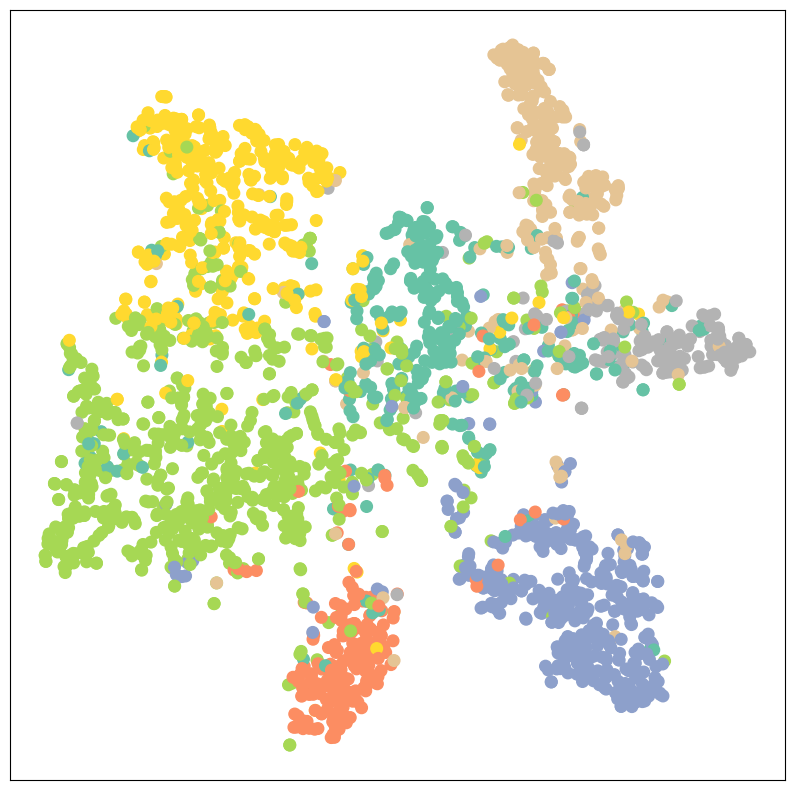

In [16]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)